# Precision-landing of a Parrot drone 

This tutorial describes the precision control of a Parrot drone to perform a precision landing, the drone is roughly 30\*30cm and should land in a 60\*60cm area inside a box.

# Introduction 

## System description

The drone is a Parrot Anafi AI, controlled either via speed or via position command (performed using its internal controller). 
The drone starts a few meters above and a few meters away from the box. 
Initial strategy was to perform image recognition to locate the box, but a more robust solution was to use a QR-code to perform quick and precise recognition of the box's center:

![drone real](images/drone_real-min.jpg)

The difficulty of the project lies in the fact that the drone is remotely controlled : computation is made on an external PC. The overall system is subject to communication delays when sending commands or receiving data from the drone. 
The data that are shared are the drone's odometry and the video flux from its camera.


![simple diagram](images/simple_diagramm.jpg)

Drone's internal odometry is noisy and subject to disturbances, especially when being close to the ground, this motivated the choice of using the camera for a consistant relative pose estimation. 

## Control goals

Our control goals are the following :
1. Ensure the drone lands **inside** the target
2. With less priority, ensure correct orientation of the drone when landing


# 1. QR code detection

## QR code selection

In this project, we propose to detect the target based on one or multiple QR-codes attached to it. To do so, we will leverage open source Aruco markers which can be detected by the cv2 library in ~10ms (See [Open CV](https://docs.opencv.org/4.x/d5/dae/tutorial_aruco_detection.html) documentation). Each marker is member of a dictionary set and is storing an ID (See [Aruco generator](https://chev.me/arucogen/)) which allow recognizing and discriminating them precisely.

![qr example](images/qr_example.svg)

Example of a marker of ID 0.

### QR code size

Putting the right QR-code dimension on the target for robust detection is a problem in itself.
Choosing the QR code size was made upon following the following parameters :
- Drone's range of altitude before landing : 0 to 10 m height
- Drone's camera Field Of View (FOV) : 68° in video mode from Parrot specifications
- Minimum number of pixels for Aruco detection : This is a bit unclear, [forums](https://github.com/zsiki/Find-GCP#:~:text=The%203x3%20or%204x4%20ArUco%20markers%20on%20the%20image%20should,50%20m%20above%20the%20ground.) state 20 to 100 pixels of width for good recognition
- Camera resolution : 1920*1080 pixels from Parrot specifications

For instance, if drone is at 10 meters, it sees

$$
\text{Scene width} = 2 \cdot \tan\left(\frac{68^\circ}{2}\right) \cdot 10 \approx 13.49,\text{m}
$$

As a rule of thumb, the drone sees roughly the same width as its altitude. If we want to find the right QR code size for this altitude, we use the fact that  **13.49 meters are projected into 1920 pixels**, meaning that a pixel is: 

$$
\text{Pixel size} = \frac{13.49,\text{m}}{1920} \approx 7.02,\text{mm/pixel}
$$

To be reliably detected, a marker should be at least **20 pixels wide**, more for robust detection and pose estimation:

**Minimum (20 px)**:

$$
20 \times 7.02 = 140.4,\text{mm} \approx \textbf{14 cm}
$$

**Optimal (100 px)**:

$$
100 \times 7.02 = 702,\text{mm} \approx \textbf{70.2 cm}
$$


From this example, we can already grasp the fact that it is really hard to use the same QR-code for all the landing process from a random position. Indeed, a 0.7m is optimal for higher heights, but won't be appropriate when the drone is below one meter.
Final choice was thus to select not one but **3 QR-codes of complementary sizes** to cover all the required altitude range:

**Conclusion (Full HD below 10 m):**

| Detection         | ID | Marker size | Approximate altitude range |
|-------------------|----|-------------|----------------------------|
| **First phase**   | 2  | 27.5 cm     | > 5 m                      |
| **Descent phase** | 1  | 15 cm       | 1 to 5 m                   |
| **Target locking**| 0  | 5 cm        | <1 m                       |





## QR code recognition

Let's now see how we can leverage information from cv2, corner positions and marker orientation in order to compute the relative position of our drone to the target.

## Relative positioning based on markers only

**1. Estimating relative position in pixel:**

When a QR code is detected, its corners coordinates and rotation angle ($\theta$) are available from cv2 in pixels. Marker center coordinates is obtained by averaging the corner positions and expressed relatively to the image center.
 
**2. Estimating distance to the QR-code**

Knowing each QR-code size in cm, the distance from the camera to a detected QR code is estimated using the apparent area of the QR in the image. Area is chosen because it is more reliable than working with the width only (geometric mean of the uncertainty).
 Let ($A_{\text{px}}$) be the pixel area of the QR code, ($W_{\text{real}}$) its real-world width of the marker, ($W_{\text{img}}$) the image width in pixels, and ($\text{FOV}$) the horizontal field of view of the camera.

First, estimate the QR code width in pixels from the area:

$$
W_{\text{px}} = \sqrt{A_{\text{px}}}
$$

The camera focal length in pixels is derived from the image width and FOV:

$$
f = \frac{W_{\text{img}}}{2 \tan(\text{FOV} / 2)}
$$

Finally, the distance to the QR code $D$ (or height $h$), in our case the drone's altitude, is estimated using the [pinhole](https://en.wikipedia.org/wiki/Pinhole_camera) camera model:

$$
D = h = \frac{W_{\text{real}} \cdot f}{W_{\text{px}}}
$$

This provides the distance in cm to the marker.

**3. Estimating relative position to the QR-code in meters**

Knowing the distance to the QR code, we can compute the number of meters per pixel meters/pixels:

$$
meters/pixel = 2 \cdot \tan\left(\frac{FOV}{2}\right) \cdot \frac{D}{\text{Scene width in pixel}}
$$

With this we directly obtain the relative position of the target to the drone in meters in the camera frame.

**4. Expressing everything in world frame**

Finally, we use the QR code angle, which is fixed in world frame to obtain the relative position in world frame :

$$
\Delta x = -d \cos(\theta), \quad \Delta y = -d \sin(\theta)
$$

Note : These are obtained from camera axis definition.

$$
x_{world} = y_{\text{drone}} + \Delta x, \quad y_{0, world} = x_{\text{drone}} + \Delta y
$$


**5. Handling Multiple QR Codes of Different Sizes**

We leverage the fact that cv2 can detect multiple QR codes at the same time to construct a robust estimation. Each QR code ID has a fixed known size in cm and are dispatched in a known configuration. The system always selects the smaller ID it sees. QR code of ID 0 is actually the center of the target, if QR code 1 or 2 are detected, we compensate for the actual target position using distances $d_{02}$ or $d_{01}$ being QR code 0 and its neighbors.

```python
QR_code_sizes = {"0": 5.0, "1": 15, "2": 27.5, "02": 17.5, "01": -11}  # cm
```

### Results 

Following example show the recognition leveraging the 3 QR codes to estimate the relative position of the drone to the QR code :

![qr](images/3_qr_example_half.gif)

### Note : Managing uncertainty

We could do a bit better than what have been exposed by estimating the position with all available QR codes and by fusing it with a weighted average approach. This would allow to always use the maximum amount of available information.

### Note :  Video flux

Video flux is treated in RTSP using gstreamer and cv2. Image resolution has been reduced to optimize latency and color set to grayscale. This is actually the most difficult part of the project but should be treated in a separate topic.

# 2. Drone control in ideal case

Let's start to design of our controller in an ideal case, i.e. when the controller is having perfect information from the environment, perfect camera reading and perfect communication.

## The basics : PID control

We will control our drone based on the relative position to the target, which is :

$$
e = (x_{drone}-x_{target},y_{drone}-y_{target},z_{drone}-z_{target},\theta_{drone}-\theta_{target})
$$

all expressed in meter.

All dimensions : x, y, z and theta can be treated with a dedicated PID of the form :

$$
u(t) = K_p \, e(t) + K_i \int_0^t e(\tau) \, d\tau + K_d \frac{de}{dt},
$$

where:
- $u(t)$ is the command in cm in a direction,
- $K_p$ is the proportional gain,
- $K_i$ is the integral gain,
- $K_d$ is the derivative gain,
- $e(t)$ is the error between the target and the drone.

**Note** : z-axis will be controlled with a constant speed of -0.2m/s. Moreover, overall speed vector is normalized to 1, meaning z-component might be reduced if x/y components are high.

## Drone model
### Linear model

Parrot Drone has position-control or stick-control modes. Position control ensures the drone reaches the correct position, but at a cost of non-constant speed  because of speed jerks, at the opposite, stick is giving a constant speed to the motors, resulting in smooth movement, which is however more subject to environmental forces such as wind.

Mathematically, a stick-control drone can be seen as "pure-integrator", it integrates the commands to give drone's position :

$$
x(t) = \int_0^t u(\tau) d\tau 
$$

The reality is a bit more complex but this will be enough to grasp the following examples.

### Landing phase

Parrot Drones can't be landed using z-speed only, it has to be put to LANDING-MODE, resulting in a direct descent to the ground, without $x/y/\theta$ control. This LANDING mode is activated in the simulation when the drone is **below 40cm and above the target**. 
Moreover, this landing phase in not always precise due to the fact that air from drone's rotors is pushed back to the drone itself when approaching the ground resulting in wobbles. This is simulated by adding a random normal noise to the speed vector during the landing phase :

$$
\tilde{u(k)} = u(k) + \epsilon,~\epsilon\sim \mathcal{N}(0, \sigma^2)
$$

We set $\sigma =0.1$ meaning the drone can suffer from non-negligible variations during this phase. This matches our observations that the drone can move laterally up to 10-15cm during landing. 

## First example

PID will take the shortest x/y path and generate straight lines in absence of yaw errors, z speed is set to constant -0.2m/s. The effect of the LANDING-MODE activated at 40cm above the ground shows the difficulty to perfectly reach the center at the right time.
In this example, only $K_p$ coefficients are non-zero:



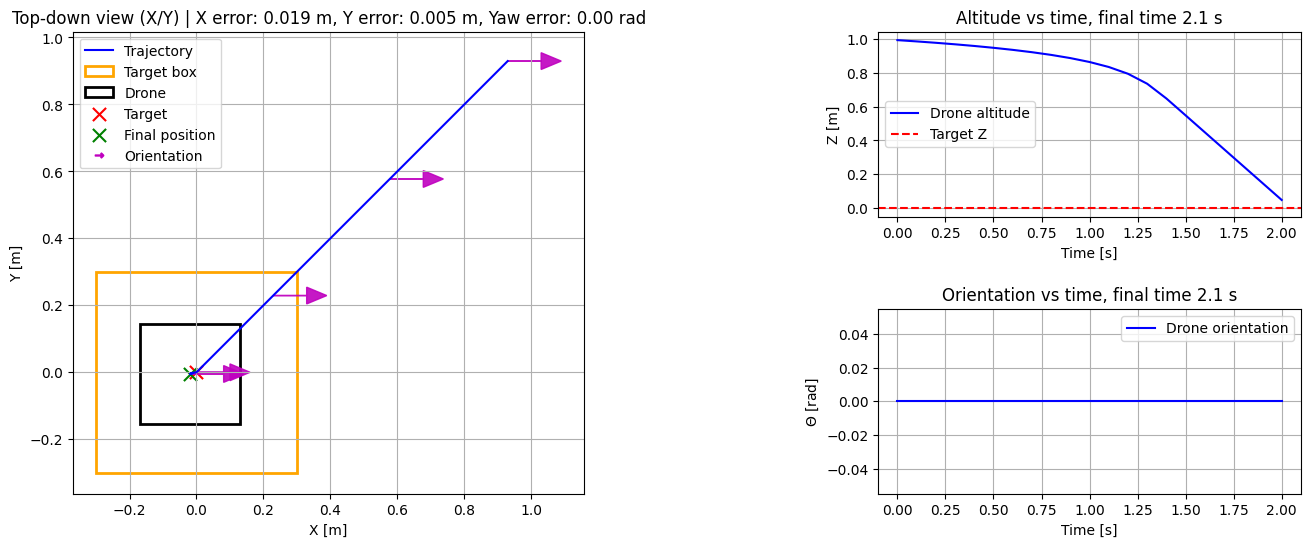

In [1]:
from DroneEnv import DroneLandingEnv
from PIDCon import PIDController
from PID_run import run_pid_simulation
import plotly.io as pio
pio.renderers.default = "notebook"

sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt)
controller_dt = 0.1  # controller step (1 Hz)

pid = PIDController(Kp=[2.0,2.0,0.0, 0.0], 
                    Ki=[0.0,0.0,0.0,0.0], 
                    Kd=[0.0,0.0,0.0,0.0], 
                    dt=controller_dt, 
                    integral_limit=0.5, 
                    z_fixed_speed=-0.2)

states, target = run_pid_simulation(
        env = env,
        pid = pid,
        init_mode='fixed',
        plot=True)


## How to handle yaw

Previous example was assuming correct yaw. When using a PID for yaw as well, we obtain more complex, less straightforward trajectory, as the drone is rotating while moving.

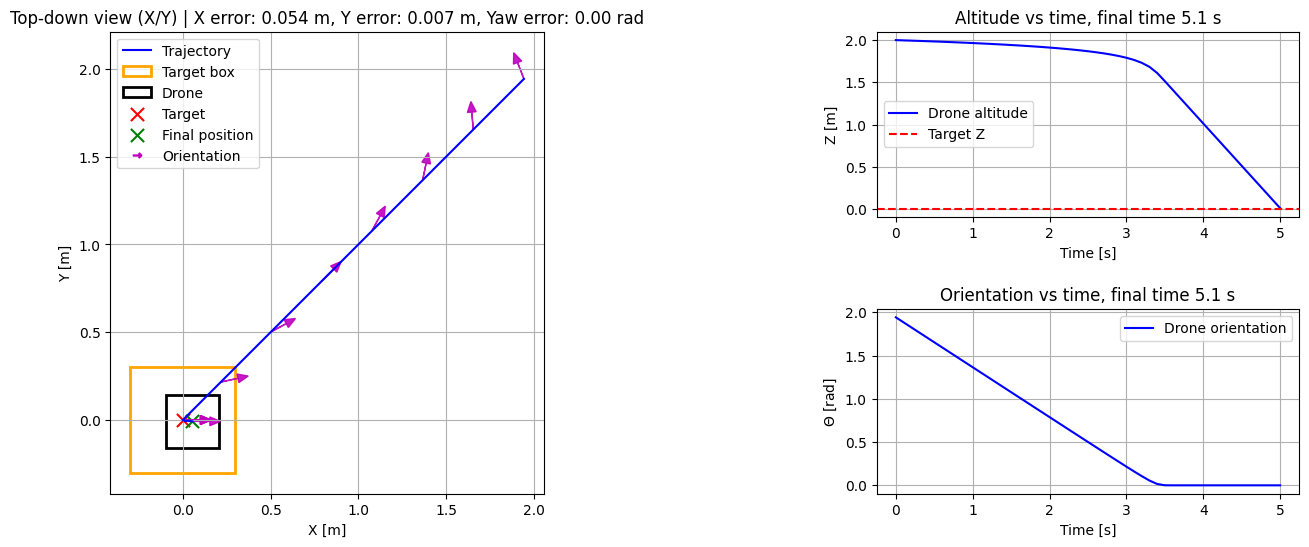

In [2]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt)
controller_dt = 0.1  # controller step (1 Hz)

pid = PIDController(Kp=[2.0,2.0, 0.0, 2.0], Ki=[0.0,0.0,0.0,0.0], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed=-0.2) #, z_fixed_speed= -0.2)

states, target = run_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0])

## Tuning with delay

Something we did not consider is the computation+communication delay between the drone and the computer. This means that the controller acts as a fixed lower frequency than the drone (10 Hz simulation here). For the simulation, we now set the controller frequency to 1 Hz, meaning that drone actions are updated 10 times slower than the simulation. 

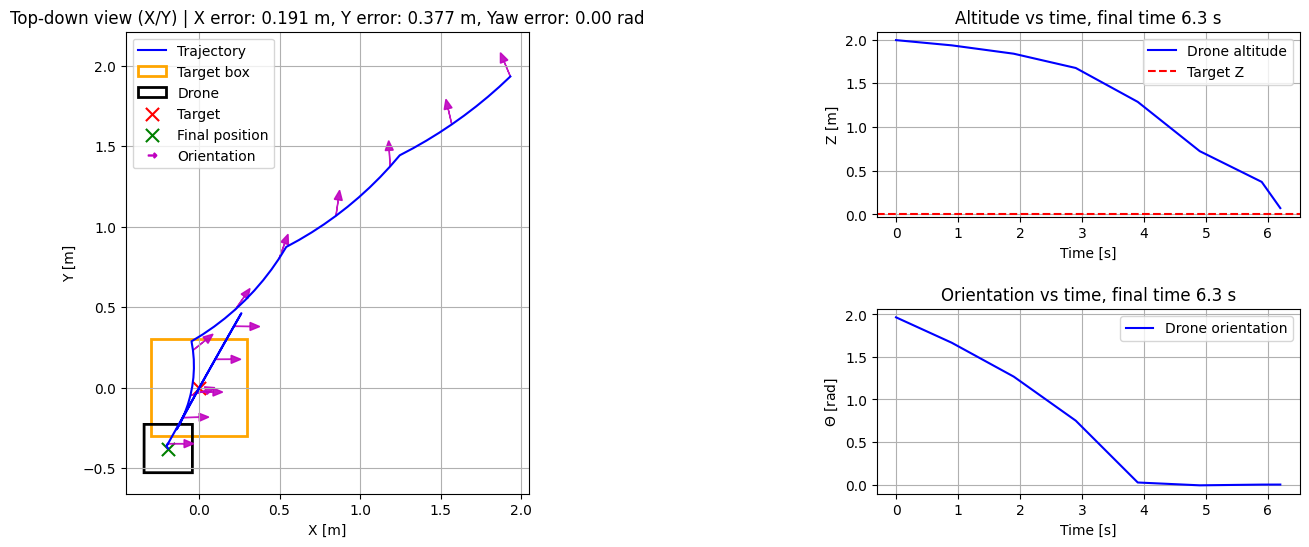

In [3]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt)
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[1.0,1.0, 0.0, 0.5], Ki=[0.0,0.0,0.0,0.0], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2)

states, target = run_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0])

When introducing delays, the drone oscillates around the target in a non-intended way. More specifically, delay introduction :
- 1) makes the drone turning around itself which causes a deviation from the target
- 2) can make the drone oscillates around the target in $x/y$ direction

Because of the introduction of the delay, the stability of the controller is reduced, the controller manages to keep the drone in a bounded area around the target but fails making it smoothly converging to it.

To solve the first issue, we will treat the yaw ($\theta$) axis in 3-steps:
- No yaw movement if the drone is more than 0.3m away of the target
- Yaw movement only when the drone is above the target
- Yaw + x/y axis if the drone is 0.3m close to the target and the yaw is small enough

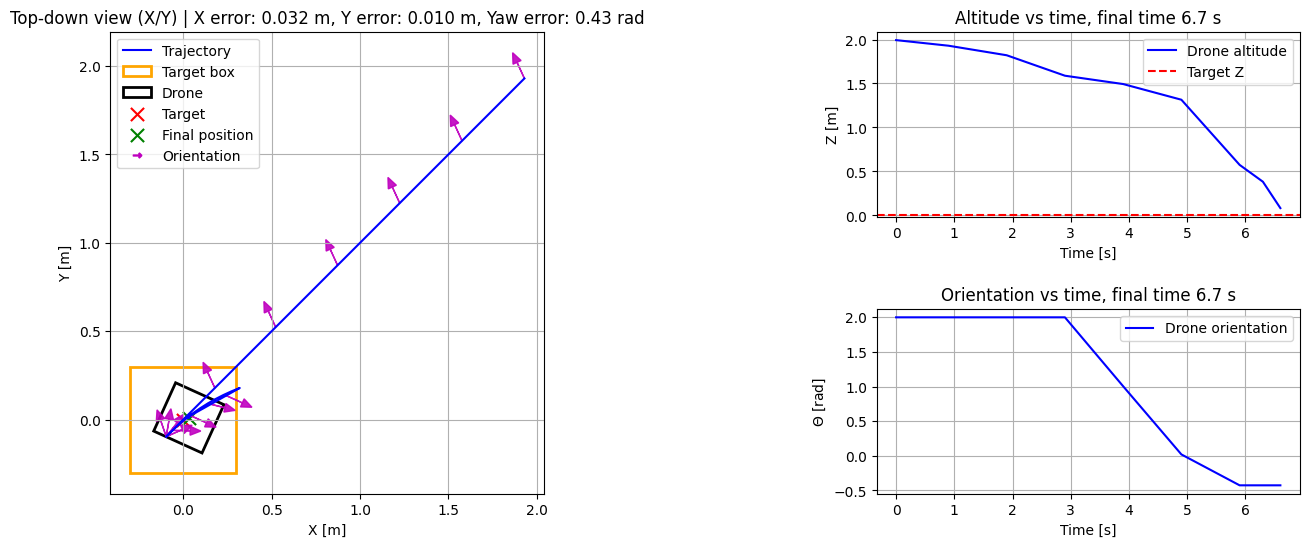

In [4]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt)
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[1.0,1.0, 0.0, 1.0], Ki=[0.0,0.0,0.0,0.2], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, yaw_3_steps =True, z_fixed_speed=-0.2)

states, target = run_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0])

And the second issue can be treated with smoother control (lower coefficients) when being closer to the target: coefficients are divided by 4 when being above the target.

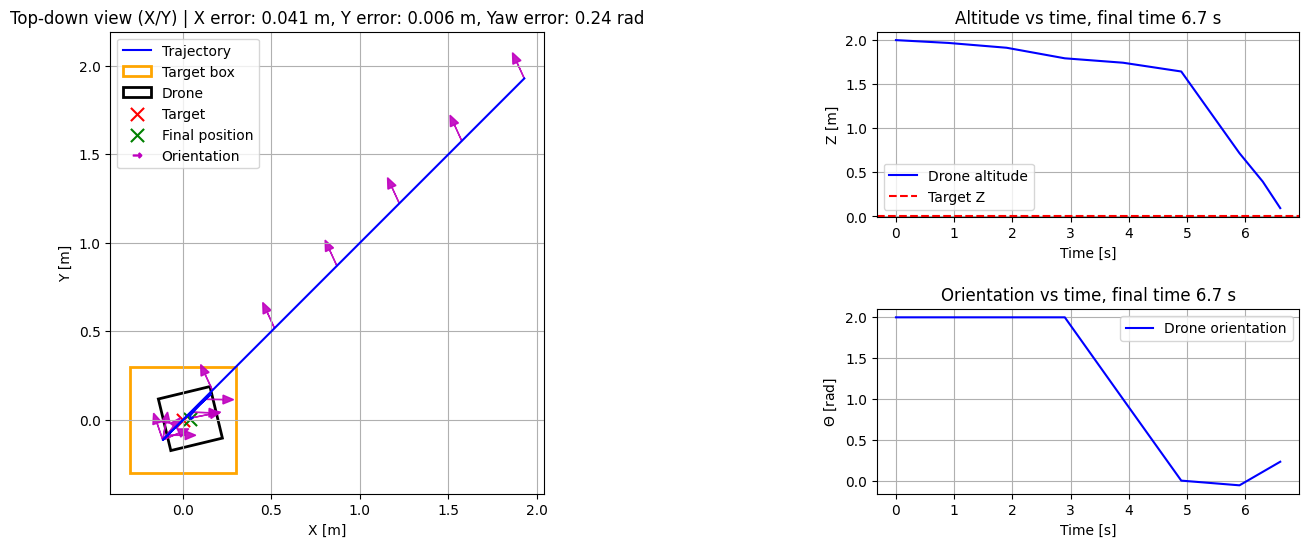

In [5]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt)
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[2.0,2.0, 0.0, 2.0], Ki=[0.0,0.0,0.0,0.0], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_3_steps =True, finer_gains=True)

states, target = run_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0])

# 3. Drone control in real situation - Study of the impact of wind, delay and losses

## Well that's done, what could go wrong in real life?

In a real setup, such a system faces the following issues :
- External unknown wind
- Measurement noises
- Packet dropout
- Non-fixed communication delays

![complex diagram](images/complex_diagram.jpg)

## Wind effect

Wind is off course the unknown component of our problem. It could be theoretically roughly estimated using drone's sensors but rather than relying on a potential estimation of the wind, we rather focus on making our drone's controller robust to disturbances. To do so, we implement the following 2-fold process for wind simulation. First, for each experiment we draw a general wind vector which will stay in a fixed direction and magnitude. Then, at each timestep, we consider a small variation around this wind vector to model uncertainty. 


We model the wind as a combination of a fixed global component and a small random fluctuation.

First, a constant wind vector is uniformly drawn at the beginning of each experiment, first by drawing its amplitude :

* **Low wind:**

$$
w_{\text{base}} \sim \mathcal{U}(0.01,0.1) \quad \text{[m/s]}
$$

* **High wind:**

$$
w_{\text{base}} \sim \mathcal{U}(0.1,0.25) \quad \text{[m/s]}
$$

where ($ \mathcal{U}(a,b) $) is the uniform distribution.

The **wind direction** is then drawn uniformly from all possible angles:

$$
\theta \sim \mathcal{U}(0,,2\pi)
$$


Then, at each timestep $(k)$, the effective wind is modeled as:

$$
w_k = w_{\text{base}}  + \delta_k, \qquad \delta_k \sim \mathcal{N}(0, \sigma_w^2 I),
$$

where ($\delta_k$) represents zero-mean Gaussian noise with standard deviation ($ \sigma_w $ ).

The drone’s velocity update is then perturbed as

$$
v_{k+1} = u_k +  w_k,
$$

with ($u_k$) the commanded velocity in the world frame and ($\Delta t$) the simulation timestep.






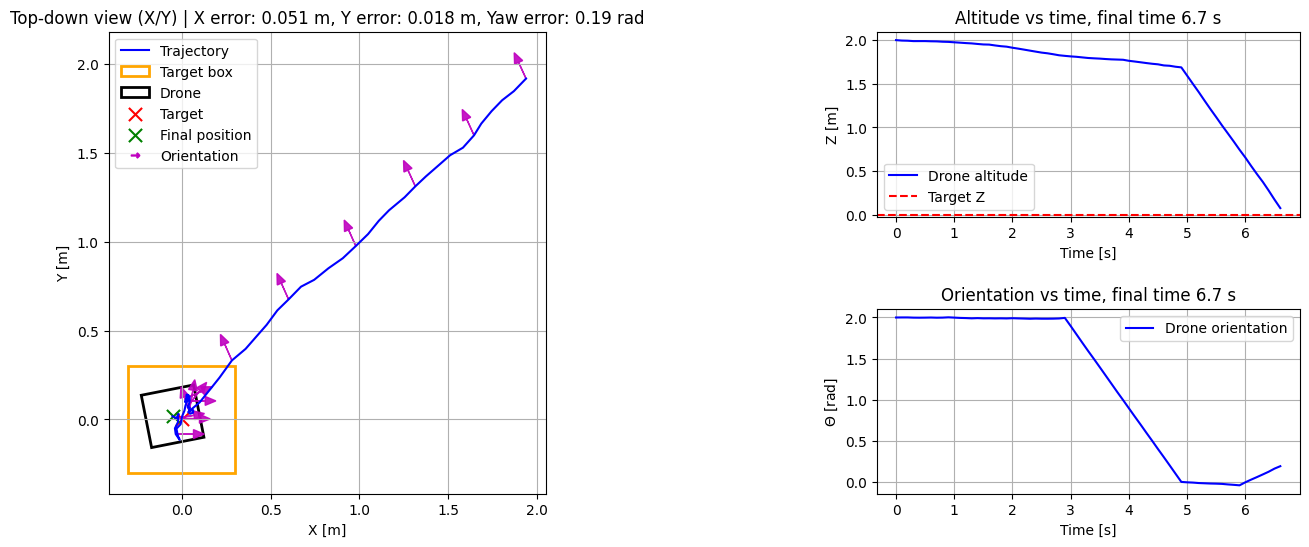

In [16]:
from PID_run import run_noisy_pid_simulation
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt, consider_wind = 'low')
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[2.0,2.0,0.0, 2.0], Ki=[0.0,0.0,0.0,0.0], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_3_steps =True, finer_gains=True)

# Delay and Packet dropout parameters
wind_std=[0.1, 0.1, 0.02, 0.02]

states, target = run_noisy_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0], max_delay_steps = 0, p_loss = 0, wind_std = wind_std, noise_std = 0.0)


In this case, the drone has to counteract the constant wind by adapting its own speed to the wind. This is the role of the integral contribution of the PID controller. Here, proportionnal gains are reduced and small $K_i$ coefficients helps to reach the center with more precision (up to the precision of the drone landing sequence).


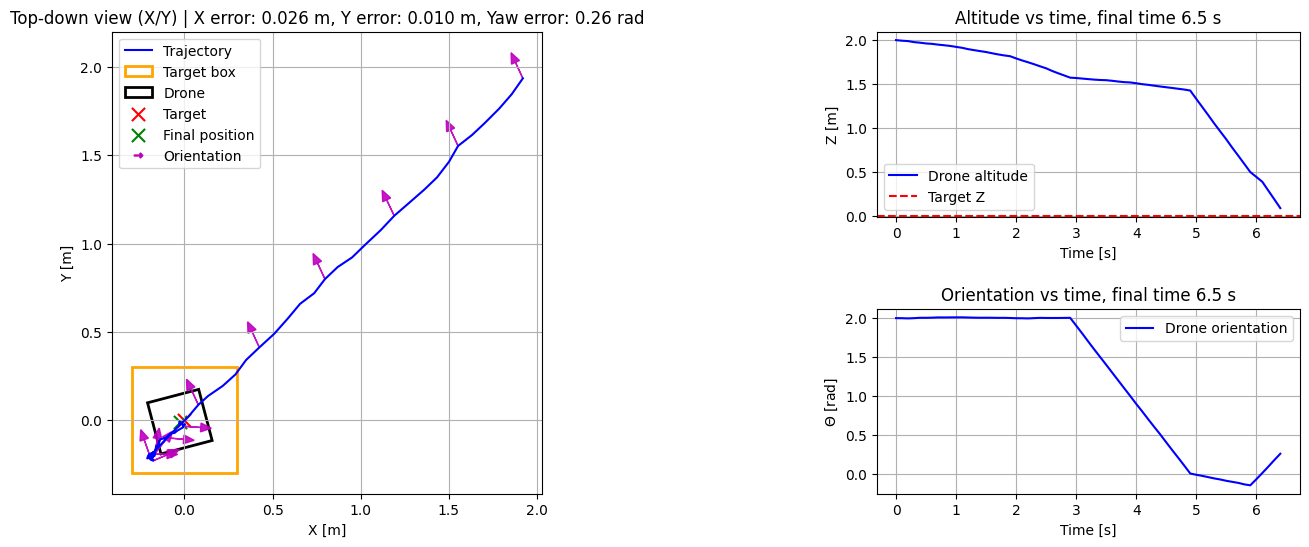

In [17]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt, consider_wind = 'low')
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[1.0,1.0,0.0, 2.0], Ki=[0.1,0.1,0.0,0.05], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_3_steps =True, finer_gains=True)

# Delay and Packet dropout parameters
wind_std=[0.1, 0.1, 0.02, 0.02]

states, target = run_noisy_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0], max_delay_steps = 0, p_loss = 0, wind_std = wind_std, noise_std = 0.0)


**Note** : Derivative contribution of PID helps to react to quick changes in the system. As it is harder to tune, its use is not presented here. 

## Sensor noise

As with every sensing devices, our control loop is subject to various noises, among which :
- GPS accuracy
- Accelerometer and gyroscope noises
- Camera pixel accuracy

All data coming from the drone's sensors are fused internally using a Kalman filter. However, GPS can be disturbed easily, especially when being close to the ground. And relying on the homemade drone estimation that we don't control (especially on altitude estimation) can be risky for our target level of precision.
During the project, decision was taken to focus on the camera for directly estimating the relative position to the target. 
Camera is not really subject to noise, but to model the pixel's accuracy, small noise is added before the controller, of the following form :

We model sensor noise by applying a multiplicative Gaussian perturbation directly on the error signal. For each controller step $(k)$, the noisy error is

$$
\tilde{e}_k = e_k \cdot \left( 1 + \eta_k \right),
$$

with

$$
\eta_k \sim \mathcal{N}(0, \sigma^2),
$$

where

* $e_k \in \mathbb{R}^4$ is the true error vector (position and yaw),
* $\tilde{e}_k$ is the noisy estimate of the error,
* $\sigma $ is the standard deviation of the noise (here ($\sigma = 0.01$)).

This corresponds to an estimation precision of a few percent, which is too small to significantly degrade controller performance, but still reflects the imperfect sensing conditions.


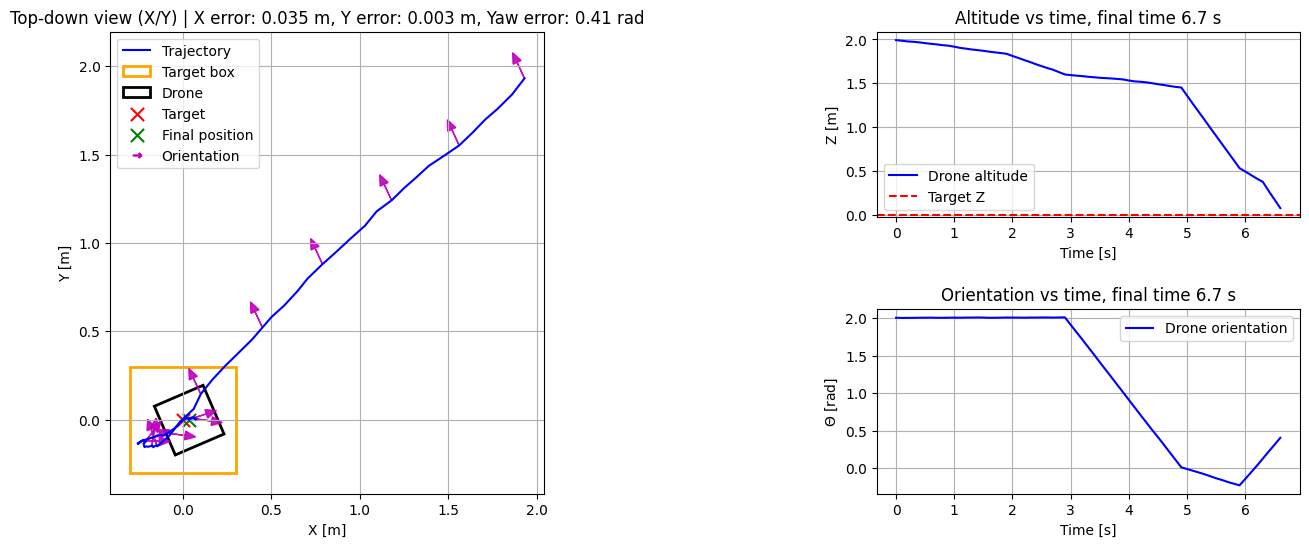

In [22]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt, consider_wind = 'low')
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[1.0,1.0,0.0, 2.0], Ki=[0.1,0.1,0.0,0.05], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_3_steps =True, finer_gains=True)

noise_std = 0.01
wind_std=[0.1, 0.1, 0.02, 0.02]

states, target = run_noisy_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0], max_delay_steps = 0, p_loss = 0, wind_std = wind_std, noise_std = noise_std)




## Packet dropout

Having a wireless communication implies being subject to various potential issues, among them, the risk of Packet dropout is the risk of losing one or multiple information. This is particularly detrimental when the communication frequency is low, because losing one packet means waiting twice the amount of time before getting an information. In different communication protocol, the risk of Packet dropout is in general reduced when the latency is increased, because more security is taken to ensure the message is delivered, even if it arrives later. From experiments, Packet dropout is particularly likely when the drone is close to the ground, because the antenna is partially targeting to the ground. 
In our simulation, we model the risk of Packet dropout in a Bernoulli experiment way, at each controller step, there is a $p$ risk that the information is dropped. This $p$ probability is fixed despite the fact that the risk is a higher when drone altitude is lower.

$$
X_k \sim \text{Bernoulli}(1-p),
$$

where
($X_k = 1$) means the control packet is successfully received,
($X_k = 0$) means the packet is lost,
($p \in [0,1]$) is the probability of Packet dropout.
Thus, the applied control at time ($k$) is

$$
u_k^{\text{applied}} = X_k , u_k + (1 - X_k) , u_{k-1}^{\text{applied}},
$$

meaning the new control ($u_k$) is applied if the packet is received, otherwise the last valid control is reused.






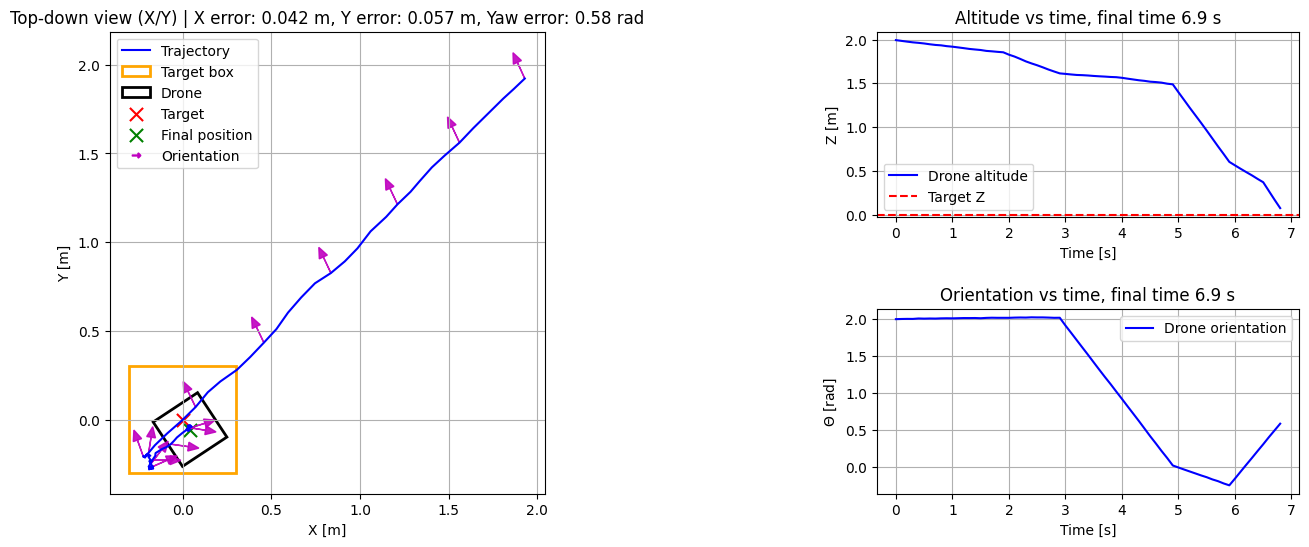

In [24]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt, consider_wind='low')
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[1.0,1.0,0.0, 2.0], Ki=[0.1,0.1,0.0,0.05], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_3_steps =True, finer_gains=True)

# Delay and Packet dropout parameters
p_loss = 0.25      # Packet dropout probability
max_delay_steps = 0  # 1 or 2 sim steps additional delay
wind_std=[0.1, 0.1, 0.02, 0.02]
noise_std = 0.01

states, target = run_noisy_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0], max_delay_steps = max_delay_steps, p_loss = p_loss, wind_std = wind_std, noise_std = noise_std)


## Non-fixed delays

Finally, we add to the simulation a last type of disturbance in the control loop : non-fixed delays. Indeed, because of the amount of information that are being transferred (live video flux), the evolution of the drone position and orientation, communication can suffer from a non-fixed delay of communication. Previously, fixed-delay was taken into account by considering different running frequencies between the drone simulation (10 Hz) and the controller (1 Hz), meaning that the total time of sending - compute - sending back was 1s, or that one side of communication takes roughly 0.5s . Now, we consider that these times might be non-constant, to do so, we consider that an action theoretically received at time $t$ can actually be received only at time: 

$$
t+ m~\delta t
$$ 

where $\delta t$ is a simulation step (0.1s) and $m$ a random integer in [0, max_delay_in_timesteps]. From the command point of view, it gives:

$$
u^{\mathrm{apl}}_k =
\begin{cases}
u^{\mathrm{apl}}_{k-1}, & \text{if no new packet arrives at } k, \\
u_j, & \text{if packet } j \text{ arrives at } k.
\end{cases}
$$

where $k$ is a simulation step.

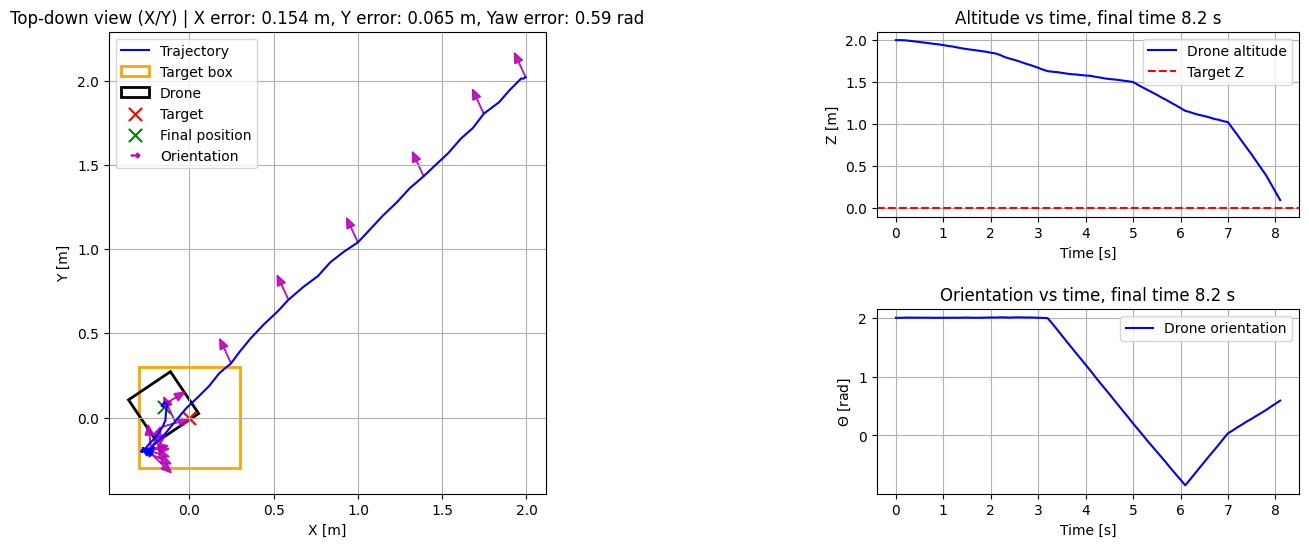

In [40]:
sim_dt = 0.1         # simulation step (10 Hz)
env = DroneLandingEnv(render_mode=None, dt=sim_dt, consider_wind='low')
controller_dt = 1.0  # controller step (1 Hz)

pid = PIDController(Kp=[1.0,1.0,0.0, 2.0], Ki=[0.1,0.1,0.0,0.05], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_3_steps =True, finer_gains=True)

# Delay and Packet dropout parameters
p_loss = 0.25      # Packet dropout probability
max_delay_steps = 3  # 1 or 2 sim steps additional delay
wind_std=[0.1, 0.1, 0.02, 0.02]
noise_std = 0.01

states, target = run_noisy_pid_simulation(env = env, pid = pid, init_mode='fixed', plot=True, init_pos = [2.0,2.0,2.0,2.0], max_delay_steps = max_delay_steps, p_loss = p_loss, wind_std = wind_std, noise_std = noise_std)


## Putting everything together

Next examples will start from a uniform random position around the target defined from the following : 

$$
x \sim \mathcal{U}(-2.0,, 2.0), \quad
y \sim \mathcal{U}(-2.0,, 2.0), \quad
z \sim \mathcal{U}(1.0,, 5.0), \quad
\theta \sim \mathcal{U}(-\pi,, \pi).
$$

From previous example, we also reduce PID coefficients by a factor 2 to incentive for more stability. We run 3 experiments as example :


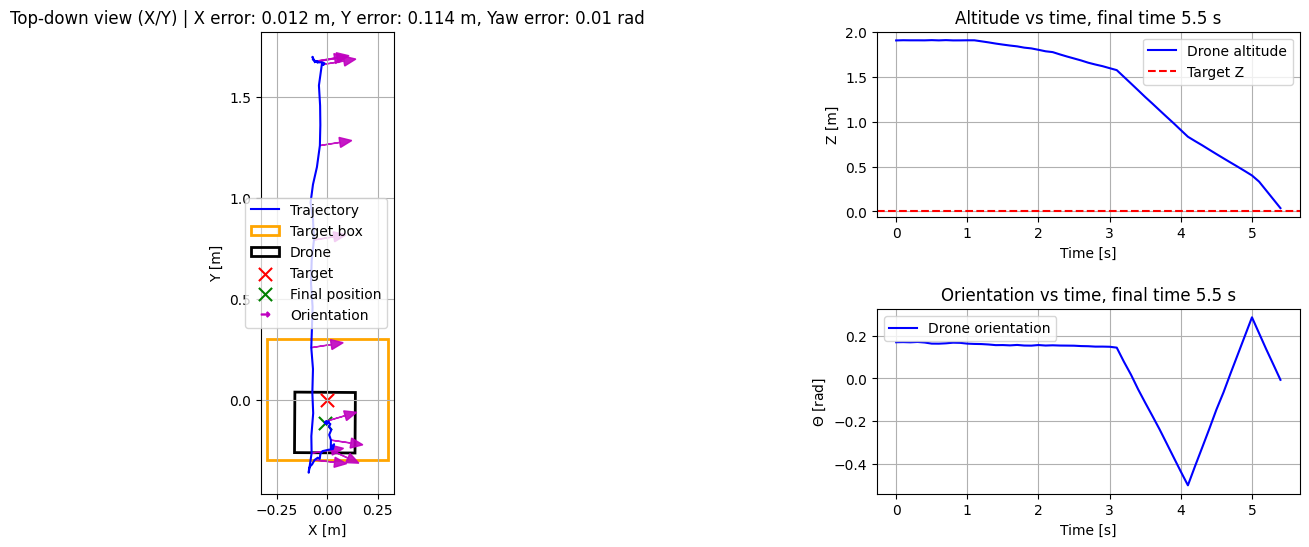

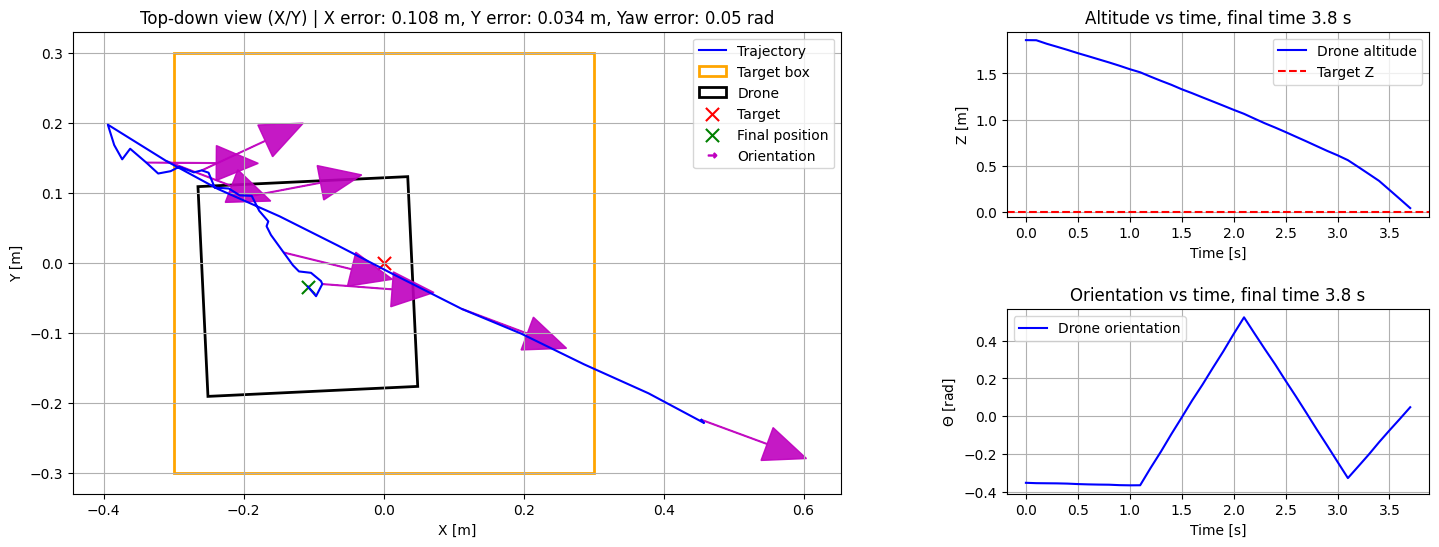

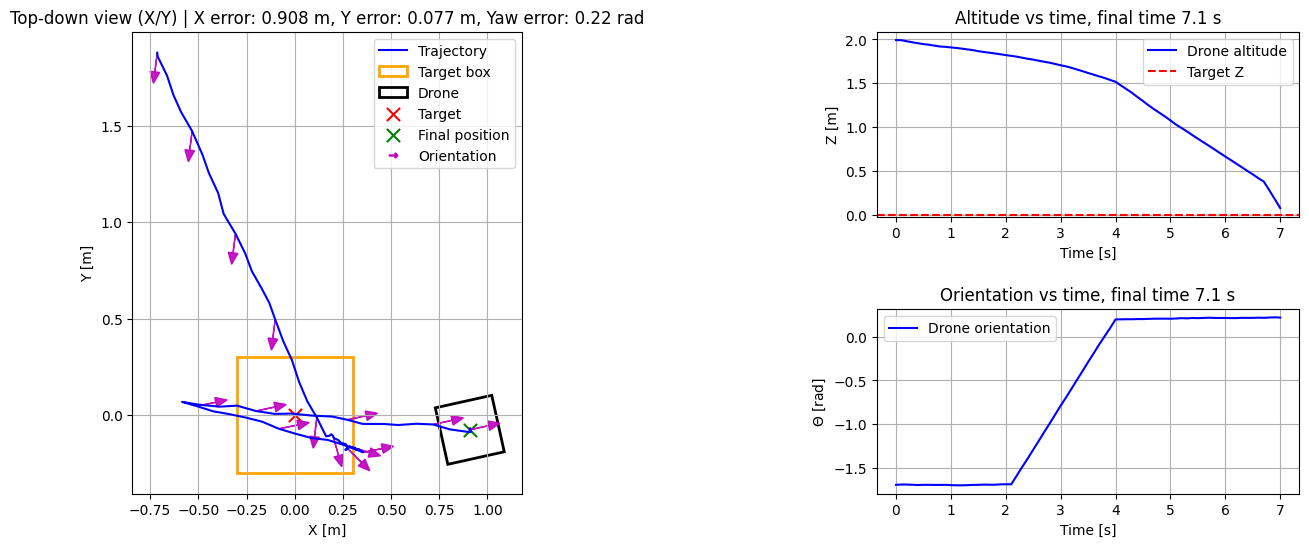

In [59]:
from PID_run import run_noisy_pid_simulation
sim_dt = 0.1         # simulation step (10 Hz)
controller_dt = 1.0

# Delay and Packet dropout parameters
max_delay_steps = 3  # 1 or 2 sim steps additional delay
p_loss = 0.2      # Packet dropout probability
wind_std=[0.1, 0.1, 0.02, 0.02]
noise_std = 0.01

stables = []

for i in range(0,3):
    env = DroneLandingEnv(render_mode=None, dt=sim_dt, consider_wind='low')

    pid = PIDController(Kp=[1.0,1.0,0.0, 1.0], Ki=[0.1,0.1,0.0,0.05], Kd=[0.0,0.0,0.0,0.0], dt=controller_dt, integral_limit=0.5, z_fixed_speed= -0.2, yaw_3_steps =True, finer_gains=True)
    states, target = run_noisy_pid_simulation(env = env, pid = pid, init_mode='random', plot=True, max_delay_steps = max_delay_steps, p_loss = p_loss, wind_std = wind_std, noise_std = noise_std)



## Stability analysis 

We assess our controller stability and performance on a large range of random trials (15 per setup of parameters).

### Stability criterion

We define and use the two followings criterion of stability.

***Weakly stable***

The system is said to be **weakly stable** if the center of the drone is within the target area at the final time $t_f$. This can be expressed as:

$$
\left | x_{drone}(t_f)-x_{target} \right | <0.3m , ~ \left | y_{drone}(t_f)-y_{target} \right | <0.3m
$$

Where $t_f$ is the final time.

***Strongly stable***

The system is said to be **strongly stable** if **all four corners of the drone** are within the target area at the final time $t_f$. This can be expressed as:

$$
\bigl| x_{c_i}(t_f) - x_{\text{target}} \bigr| < 0.3 ; \text{m},
\quad
\bigl| y_{c_i}(t_f) - y_{\text{target}} \bigr| < 0.3 ; \text{m},
\quad \forall i \in {1,2,3,4}
$$

Where $t_f$ is the final time and $c_i$ a corner number.


Weak stability indicates a bounded stability, strong stability is still technically a bounded stability, but might indicate an asymptotic stability (See [here](https://en.wikipedia.org/wiki/Lyapunov_stability) for the mathematical definitions.

### Results

We can plot the average number of weakly/strongly stable trials in a large number of simulation w.r.t. each parameter: 

**Weak stability**

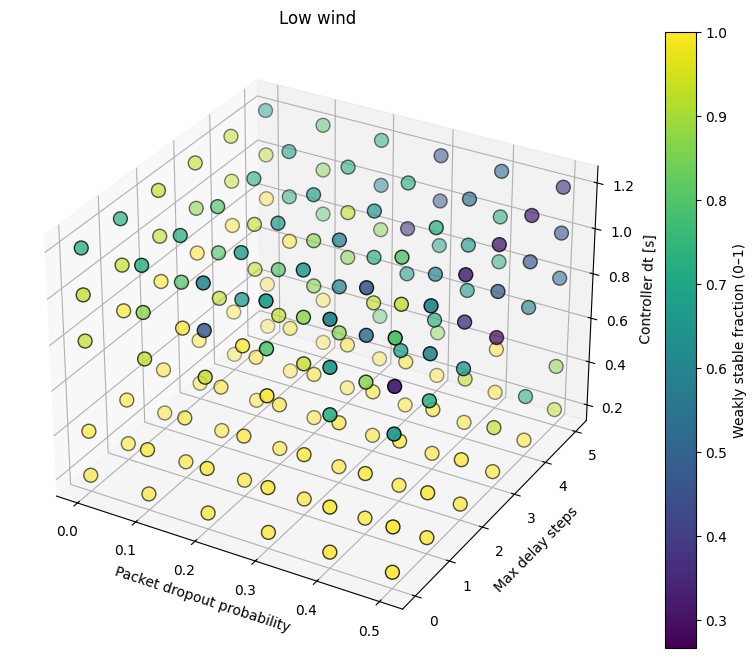

In [2]:
from PidEval import sweep_parameters, show_stability_volume

results = sweep_parameters('low', noise_std=0.01)
sc = show_stability_volume(results, title=f"Low wind", weak_stability=True)

Below is the evolution of our weak stability criterion for the different type of winds:

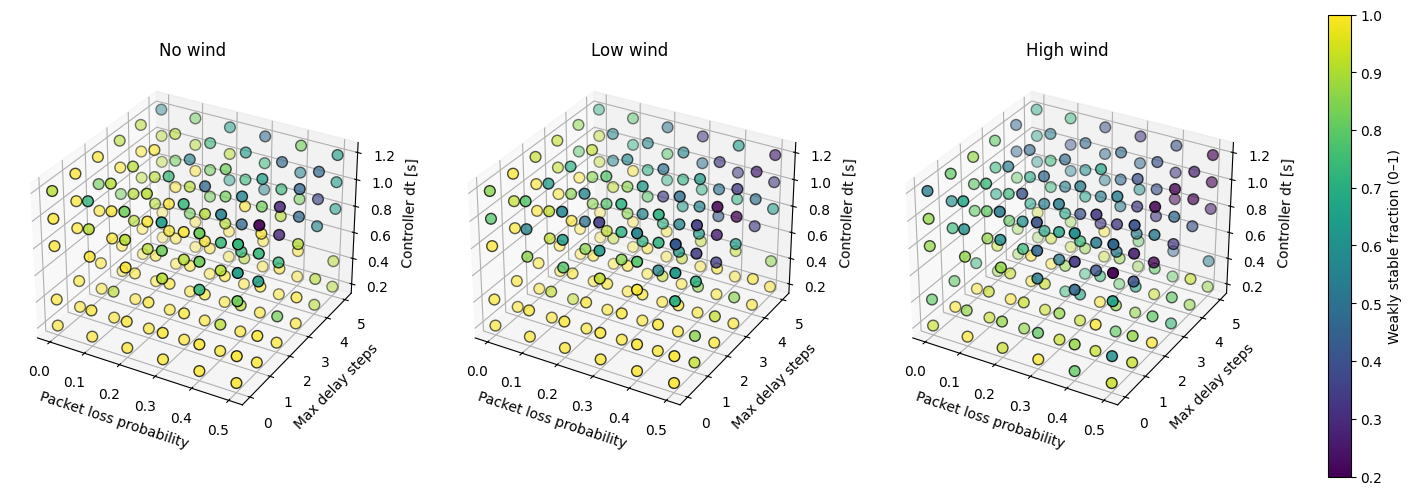

In [53]:
from PidEval import sweep_parameters, plot_stability_volume
import matplotlib.pyplot as plt

noise_std = 0.01

# Three wind scenarios
wind_scenarios = {
    "No wind":  'off',
    "Low wind":  'low',
    "High wind": 'high',
}

# Create 1×3 subplot grid
fig, axes = plt.subplots(1, len(wind_scenarios), figsize=(20, 12), subplot_kw={"projection": "3d"})

for ax, (label, wind_type) in zip(axes, wind_scenarios.items()):
    results = sweep_parameters(wind_type, noise_std)
    sc = plot_stability_volume(results, title=f"{label}", ax=ax)

# Add one shared colorbar for all subplots
fig.colorbar(
    sc, ax=axes, orientation="vertical",
    label="Weakly stable fraction (0–1)", shrink=0.5 )

plt.show()


**Note** : We could remove cases where delay_steps>controller_dt which are not feasible.

**Strong stability**
Below is the same analysis for the strong stability criterion

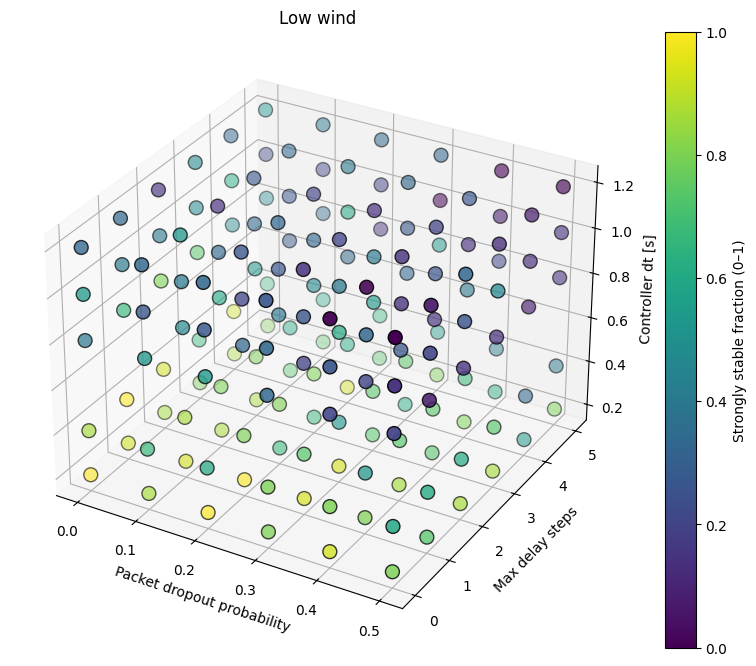

In [4]:
results = sweep_parameters('low', noise_std=0.01)
sc = show_stability_volume(results, title=f"Low wind", weak_stability=False)

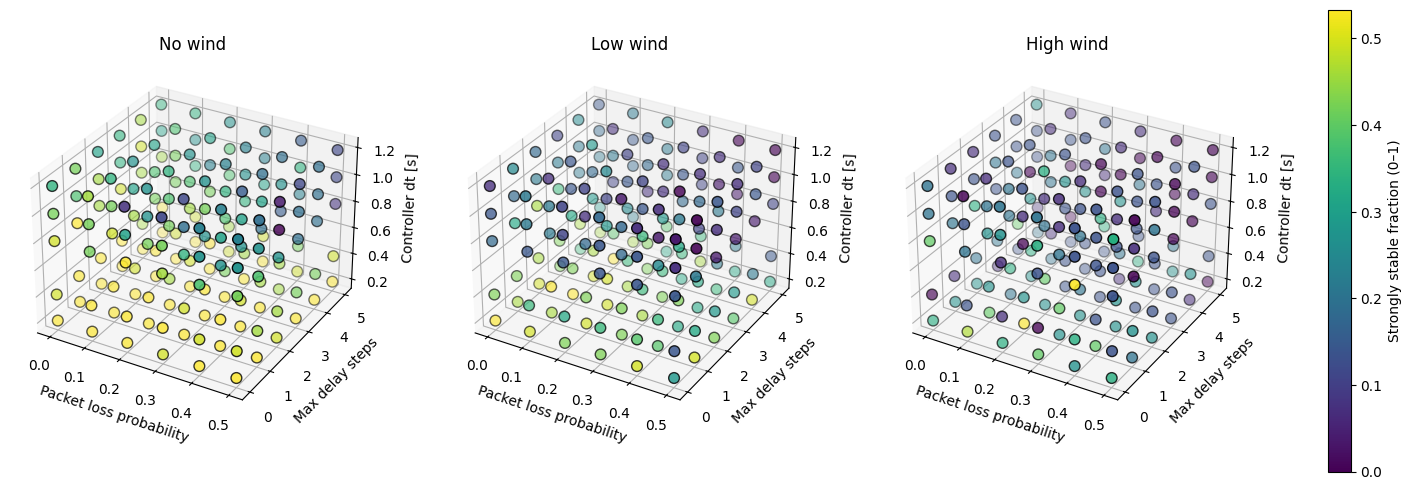

In [56]:
noise_std = 0.01

# Three wind scenarios
wind_scenarios = {
    "No wind":  'off',
    "Low wind":  'low',
    "High wind": 'high',
}

# Create 1×3 subplot grid
fig, axes = plt.subplots(1, len(wind_scenarios), figsize=(20, 12), subplot_kw={"projection": "3d"})

for ax, (label, wind_type) in zip(axes, wind_scenarios.items()):
    results = sweep_parameters(wind_type, noise_std)
    sc = plot_stability_volume(results, title=f"{label}", ax=ax, weak_stability=False)

# Add one shared colorbar for all subplots
fig.colorbar(sc, ax=axes, orientation="vertical", label="Strongly stable fraction (0–1)", shrink=0.5)
# plt.tight_layout()
plt.show()

# Conclusion

## Some takeaways : Having proper tuning is not enough 

While the problem is technically simple in concept (first-integrator model), its difficulty arises from the numerous **implementation challenges** that can affect system stability. Among these challenges are:

* **Unstable connections**
* **Noisy sensors**
* **Slow computation**


All of these factors can degrade performance, particularly when aiming for a highly precise system. We defined **strong stability** as the condition in which all drone corners land within the target. Achieving this level of precision requires that:

1. Each component behaves reliably.
2. The system as a whole can cope with disturbances.


However, the combination of technical disturbances—like delays, noise, and Packet dropout—can prevent the system from maintaining strong stability against varying environmental conditions such as wind.

Concluding on the exact impact of each parameter is a bit tricky, however we can tell that:

* **Controller update rate (`dt`)** has the largest impact.

  * Additional delay steps effectively reduce the control frequency, acting as a **frequency divider**.
* When the controller frequency is high, the system can tolerate **Packet dropout probabilities up to 0.2–0.3** without major issues.
* As the control frequency decreases, even moderate Packet dropout increasingly limits the drone’s stability.

Improving your controller rate might actually be more useful than tuning your gains !


### Could we prove all of this?


Actually yes we can obtain these curves analytically ! Look at [Wikipedia](https://en.wikipedia.org/wiki/Networked_control_system) for some references or the book from [Francesco Bullo](https://ucsb.app.box.com/v/LecturesNetworkSystems) for the extensive theory about it.


### Note on code and LLM usage


This tutorial aims to present and discuss different technique usage. 
Some technical slackness has sometimes been taken to simplify some aspects, without notification.
The initial project has been made in Python, simulator has been created partly using LLMs (OpenAI and Mistral)


